# Visión por Computadora II - Trabajo Final

## Integrantes

- Acevedo Zain, Gaspar (acevedo.zain.gaspar@gmail.com)
- Lauro, Rodrigo (ing.rodrigo.lauro@gmail.com)
- Rodrigues da Cruz, Nicolás (Nicolasrdc151@gmail.com)

## Descripción del problema

- Tipo de problema: Clasificación
- Descripción: Detección de nódulos pulmonares en tomografías de tórax.
- Detalles: Desarrollar un modelo de aprendizaje profundo que identifique la presencia de nódulos pulmonares en imágenes de tomografía computarizada (CT) de tórax.​
- Dataset: [Chest CT-Scan images Dataset](https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images)

## Resultados obtenidos

***Objetivo***

En este notebook se utiliza una arquitectura [ResNet152](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet152.html) a fin de resolver el problema de clasificación de nódulos pulmonares planteado en este proyecto.

***Experimentos realizados***

Con esta arquitectura se plantean las siguientes configuraciones para entrenamiento de la red neuronal:

- *Modificación del output de la última capa*: en estos casos se modifica el `output` de la última capa de la ResNet152, a fin de que coincida con la cantidad de clases a predecir ($4$ para este caso). Los experimentos de este tipo se llamarán simplemente `ResNet 152 - base`.
- *Modificación de la última capa con Transformaciones Lineales*: en estos casos se modificará la última capa, agregando una *secuencia* de tranformaciones lineales afines (mediante [torch.nn.Linear](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)). Los experimentos de este timpo tendrán en el nombre `ResNet 152 - Transformaciones lineales`.
- *Modificación de la última capa con Convoluciones customizadas*: de manera similar al caso anterior, estos experimentos aplican convoluciones custom en la última capa (mediante [torch.nn.Conv2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)). Los experimentso de este tipo tendrán en el nombre `ResNet 152 - Convoluciones en última capa`.

Además, se plantea estudiar como performan estas arquitecturas al utilizar `transfer learning` y `fine tuning`:

- `Transfer Learning`: utilizamos los modelos `ResNet152` preentrenados para trabajar en problemas de clasificación de imágenes. En estos casos, las capas están *freezados*, es decir, utilizamos los **pesos** obtenidos en el preentrenamiento (en PyTorch, con `ResNet152_Weights.IMAGENET1K_V2`). En este caso, solamente entrenamos las capas nuevas de nuestra red. Los experimentos de este tipo tendrán el sufijo `Transfer Learning`.
- `Fine Tuning`: a diferencia de *Transfer Learning*, en este caso las capas **no** están freezadas, por lo que se utilizan los **pesos** base (en PyTorch, con `ResNet152_Weights.DEFAULT`). De esta manera, nos permite que toda la red aprenda características de nuestro dataset objetivo, a fin de, por ejemplo, mejorar la métrica final de nuestro entrenamiento. Los experimentos de este tipo tendrán el sufijo `Fine Tuning`.
- ***Sources***
  - [Weight and Biases - Transfer Learning](https://wandb.ai/wandb_fc/genai-research/reports/Transfer-learning-versus-fine-tuning--VmlldzoxNDQxOTM3OQ#what-is-transfer-learning?).
  - [Weight and Biases - Fine tuning](https://wandb.ai/wandb_fc/genai-research/reports/Transfer-learning-versus-fine-tuning--VmlldzoxNDQxOTM3OQ#what-is-fine-tuning?)
  - [torchvision.models.resnet152](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet152.html)

De esta manera, se definen los siguientes $6$ experimentos:

- `ResNet 152 - Base - Transfer Learning`
- `ResNet 152 - Transformaciones lineales - Transfer Learning`
- `ResNet 152 - Convoluciones en última capa - Transfer Learning`
- `ResNet 152 - Base- Fine Tuning`
- `ResNet 152 - Transformaciones lineales - Fine Tuning`
- `ResNet 152 - Convoluciones en última capa - Fine Tuning`

***Data Augmentation***

Respecto a los datasets utilizados, se implementa el mismo `Data Augmentation` que el que se aplica para los datos utilizados al entrenar el modelo [Baseline](https://github.com/gasper-az/vision-computadora-II-trabajo-final/blob/main/trabajo-final.ipynb).

***Métricas***

Tal como se definió en la notebook donde se encuentra definido el ***baseline*** ([trabajo-final.ipynb](https://github.com/gasper-az/vision-computadora-II-trabajo-final/blob/main/trabajo-final.ipynb)), utilizaremos como métrica el ***Recall*** a fin de minimizar los ***Falsos Negativos***.

***Configuraciones comúnes***

Los $6$ modelos a estudiar, al igual que el [baseline](https://github.com/gasper-az/vision-computadora-II-trabajo-final/blob/main/trabajo-final.ipynb), tendrán las siguientes configuraciones:

- `Loss Function`: [torch.nn.CrossEntropyLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html), ya que se trata de una clasificación **multi-clase**/
- `Optimizador`: [torch.optim.Adam](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html), porque es considerado uno de los optimizadores más robustos y efectivos. Combina las ventajas de Momentum (acelerar la convergencia) y RMSprop (learning rates adaptativos por parámetro).
- `Learning Rate`: utilizamos un valor **bajo** de `1e-4` a fin de ajustar levemento los parámetros/peros del modelo ResNet152 que usamos de base ([Dive into Deep Learning - Fine Tuning](https://d2l.ai/chapter_computer-vision/fine-tuning.html)).
- `EPOCHS`: utilizamos $100$ épocas, aunque nuestra función de entrenamiento está configurada con ***Early Stopping*** con ***patience*** igual a $5$.

***Resultados obtenidos***

| Modelo | Recall (en *test*) | EPOCHS |
| --- | --- | --- |
| Baseline (*Resnet 18*) | $0.59$ | $44$ (con *Early Stopping*) |
| *ResNet 152 - Base - Transfer Learning*							  | $0.64 $ | $45$ (con *Early Stopping*)|
| *ResNet 152 - Transformaciones lineales - Transfer Learning*		  | $0.72$ | $25$ (con *Early Stopping*) |
| *ResNet 152 - Convoluciones en última capa - Transfer Learning*	  | $0.75$ | $36$ (con *Early Stopping*) |
| *ResNet 152 - Base- Fine Tuning*									  | $0.91$ | $18$ (con *Early Stopping*) |
| *ResNet 152 - Transformaciones lineales - Fine Tuning*			  | $0.88$ | $19$ (con *Early Stopping*) |
| *ResNet 152 - Convoluciones en última capa - Fine Tuning*			  | $0.90$ | $44$ (con *Early Stopping*) |

Los $2$ experimentos con mejores métricas son:

1. *ResNet 152 - Base- Fine Tuning* (Recall de $0.91$).
1. *ResNet 152 - Convoluciones en última capa - Fine Tuning* (Recall de $0.90$).

Todos los modelos resultantes de nuestros experimentos superan al *Baseline* en cuanto a métrica (Recall de $0.64$).

***Conclusiones***

Los modelos `ResNet152` presentan una arquitectura ideal para problemas de clasificación de imágenes médicas como el estudiado en este proyecto.

Al crear nuevos modelos basados en esta arquitectura, notamos que aquellos en donde implementamos `Fine Tuning` se obtuvieron mejores métricas que en aquellos en donde implementamos `Transfer Learning`, aplicando en ambos casos una serie de configuraciones similares (ver ***Configuraciones comúnes***).

Otro detalle importante a mencionar es que al analizar las **matrices de confusión** (comúnes y normalizadas por filas) de los modelos entrenados con `Fine Tuning` notamos que las clases correspondientes a enfermedades **NUNCA** son *confundidas* con la clase **Normal** (o sin enfermedad).

***Futuros experimentos***

A continuación se plantean experimentos de interés que *NO* se implementan en este proyecto, pero podrían presentar resultados útiles.

1. *Modelos sin Data Augmentation*: como el nombre lo indica, en estos experimentos se busca demostrar cómo afecta el Data Augmentation a nuestros modelos.
1. *Hyperparameter Tuning*: en estos experimentos se buscará optimizar ciertos hiperparámetros, como el *Learning Rate*, *DropOut*, tamaño de *Kernel*, entre otros (dependiendo del modelo a estudiar).

## Imports

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 20.6 MB/s eta 0:00:00


In [ ]:
import torchvision
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import torch
import cv2

import numpy as np
import pandas as pd

import os
from zipfile import ZipFile
from typing import Tuple
import math
import random

import matplotlib.pyplot as plt
from collections import Counter

from sklearn.decomposition import PCA

In [ ]:
from torchvision.models import resnet18, ResNet18_Weights
import torchsummary
import torchmetrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Descarga del dataset

In [ ]:
!curl -L -o "/content/dataset.zip" "https://www.kaggle.com/api/v1/datasets/download/mohamedhanyyy/chest-ctscan-images"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  118M  100  118M    0     0  62.2M      0  0:00:01  0:00:01 --:--:--  103M


In [ ]:
zip_file = "/content/dataset.zip"
dataset_unzip_folder = "/content/."
dataset_folder = "/content/Data"
DATASET_TRAIN = os.path.join(dataset_folder, "train")
DATASET_TEST = os.path.join(dataset_folder, "test")
DATASET_VALID = os.path.join(dataset_folder, "valid")

In [ ]:
# Descomprimo si NO existe la carpeta /content/dataset_emociones
if not os.path.isdir(dataset_folder):
  with ZipFile(zip_file, 'r') as zip_object:
    zip_object.extractall(path=dataset_unzip_folder)

## Data Augmentation

En esta sección se aplica el mismo `data augmentation` que se definió en la sección `EDA - Definición de Transformaciones y Data Augmentation` de la notebook [trabajo-final.ipynb](https://github.com/gasper-az/vision-computadora-II-trabajo-final/blob/main/trabajo-final.ipynb).

In [ ]:
dataset_mean = [0.485, 0.456, 0.406]
dataset_std = [0.229, 0.224, 0.225]

In [ ]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean, std=dataset_std)
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.0))
    ], p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean, std=dataset_std)
])

## Definición de datasets para los modelos

In [ ]:
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=train_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=val_test_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=val_test_transform)

Se crean a continuación los dataloaders de `train`, `test` y `validation`, utilizando un ***Batch Size*** de $32$. El único data loader con `shuffle = True` es el de `train`.

In [ ]:
BATCH_SIZE = 32

In [ ]:
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)
validation_loader = DataLoader(dataset=validation_data, batch_size=BATCH_SIZE, shuffle=False)

## Función para train-test loop

A continuación se define la función `train_eval_loop` que implementa el *loop* principal de entrenamiento. Este proceso iterará sobre el número de `EPOCHS` definido.

En cada época, se realizan dos fases:

1.  **Fase de Entrenamiento (función `train_one_epoch`):**
    * Se itera sobre el `train_loader`.
    * Se realiza el *forward pass* (propagación hacia adelante).
    * Se calcula la pérdida (***Loss***) comparando las predicciones con las etiquetas reales (usando `criterion`).
    * Se realiza el *backward pass* (retropropagación) y se actualizan los pesos del modelo (`optimizer.step()`).
    * Se acumulan la *loss* y las métricas de esta fase.

2.  **Fase de Validación (función `eval_one_epoch`):**
    * Se desactiva el cálculo de gradientes (`with torch.no_grad()`) para ahorrar cómputo, ya que en esta fase no se aprende.
    * Se itera sobre el `validation_loader`.
    * Se evalúa el rendimiento del modelo sobre datos "no vistos" (el conjunto de validación).
    * Se acumulan la *loss* y las métricas de validación.

Además, se implementará un mecanismo de **Early Stopping**. Este monitoreará la pérdida de validación (`val_loss`) y detendrá el entrenamiento si esta no mejora después de un número determinado de épocas (`patience`), evitando así el *overfitting* y ahorrando tiempo de cómputo.

Se almacenará el historial de *loss* y métricas de ambas fases en cada época para su posterior visualización.

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device, metric):
    model.train()
    running_loss = 0.0
    all_outputs = []
    all_targets = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        all_outputs.append(outputs.detach())
        all_targets.append(labels.detach())

    epoch_loss = running_loss / len(loader)
    outputs_cat = torch.cat(all_outputs)
    targets_cat = torch.cat(all_targets)

    epoch_recall = metric(outputs_cat, targets_cat).item()

    return epoch_loss, epoch_recall

In [ ]:
def eval_one_epoch(model, loader, criterion, device, metric):
    model.eval()
    running_loss = 0.0
    all_outputs = []
    all_targets = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            all_outputs.append(outputs)
            all_targets.append(labels)

    epoch_loss = running_loss / len(loader)
    outputs_cat = torch.cat(all_outputs)
    targets_cat = torch.cat(all_targets)

    epoch_recall = metric(outputs_cat, targets_cat).item()

    return epoch_loss, epoch_recall, outputs_cat, targets_cat


In [ ]:
def train_eval_loop(model: any, optimizer, criterion, metric, data: dict,
                    epochs: int = 100, patience: int = 5):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    history = {
        "train_loss": [],
        "valid_loss": [],
        "train_metric": [],
        "valid_metric": [],
        "labels_last_epoch": [],
        "pred_last_epoch": [],
        "test_loss": 0,
        "test_metric": 0,
    }

    train_loader = data["train"]
    valid_loader = data["valid"]

    model.to(device)
    metric.to(device)

    best_val_loss = float("inf")
    epochs_no_improve = 0

    for epoch in range(epochs):
      ####################  TRAIN STEP  ####################
      train_loss, train_recall = train_one_epoch(
          model, train_loader, optimizer, criterion, device, metric
      )

      ####################  EVAL STEP  ####################
      valid_loss, valid_recall, _, _ = eval_one_epoch(
          model, valid_loader, criterion, device, metric
      )

      ####################  Métricas del EPOCH  ####################

      history["train_loss"].append(train_loss)
      history["valid_loss"].append(valid_loss)
      history["train_metric"].append(train_recall)
      history["valid_metric"].append(valid_recall)

      ####################  EARLY STOPPING  ####################
      if valid_loss < best_val_loss:
        print(
            f"Época {epoch+1}/{epochs} | "
            f"Train loss: {train_loss:.4f} - Train recall: {train_recall:.4f} | "
            f"Valid loss: {valid_loss:.4f} - Valid recall: {valid_recall:.4f}"
        )
        best_val_loss = valid_loss
        epochs_no_improve = 0
      else:
        epochs_no_improve += 1
        print(f"=====No hay mejora en Valid Loss por {epochs_no_improve} épocas.")

      if epochs_no_improve == patience:
        print(f"\n¡EARLY STOPPING! No hubo mejora en {patience} épocas. Deteniendo entrenamiento en epoch {epoch+1}.")
        break

    ####################  TEST  ####################
    test_loader = data["test"]
    test_loss, test_metric, test_outputs, test_targets = eval_one_epoch(
        model, test_loader, criterion, device, metric)

    history["labels_last_epoch"] = test_targets
    history["pred_last_epoch"] = test_outputs
    history["test_loss"] = test_loss
    history["test_metric"] = test_metric

    return history

## Constants

In [ ]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
OUTPUTS = 4
CANT_CLASES = 4

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
LEARNING_RATE = 1e-4
EPOCHS = 100

In [ ]:
criterion = torch.nn.CrossEntropyLoss()
metric = torchmetrics.Recall(task='multiclass', num_classes=CANT_CLASES)

In [ ]:
data = {"train": train_loader, "valid": validation_loader, "test": test_loader}

In [ ]:
CLASS_LABELS = [
    "adenocarcinoma",
    "large.cell.carcinoma",
    "normal",
    "squamous.cell.carcinoma"
]

## ResNet 152 - Base - Transfer Learning

### Definición del modelo

En este caso se estudia un modelo basado en `ResNet152`, en donde solamente modificamos el ***OUTPUT*** de la última capa. Pasamos de $2048$ a $4$, que son la cantidad de clases a predecir.

Además, implementamos ***Transfer Learning***, por lo cual utilizamos los pesos obtenidos al entrenar el modelo ResNet152 (`ResNet152_Weights.IMAGENET1K_V1`).

In [ ]:
from torchvision.models import resnet152, ResNet152_Weights

weights = ResNet152_Weights.IMAGENET1K_V1
resnet152_model = resnet152(weights=weights);
resnet152_model.to(device);

Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100%|██████████| 230M/230M [00:03<00:00, 79.8MB/s]


In [ ]:
for param in resnet152_model.parameters():
    param.requires_grad = False

last_layer_in_features = resnet152_model.fc.in_features
resnet152_model.fc = torch.nn.Linear(in_features=last_layer_in_features, out_features=OUTPUTS)

### Entrenamiento

Entrenamos el modelos con un Learning Rate de `1e-4` y con $100$ EPOCHS.

In [ ]:
optimizer = torch.optim.Adam(resnet152_model.fc.parameters(), lr=LEARNING_RATE)

In [ ]:
history_resnet152 = train_eval_loop(model=resnet152_model, optimizer=optimizer,
                                    criterion=criterion, metric=metric,
                                    data=data, epochs=EPOCHS)

Época 1/100 | Train loss: 1.3628 - Train recall: 0.3197 | Valid loss: 1.4248 - Valid recall: 0.3056
Época 2/100 | Train loss: 1.2778 - Train recall: 0.4454 | Valid loss: 1.3141 - Valid recall: 0.3611
Época 3/100 | Train loss: 1.2484 - Train recall: 0.4339 | Valid loss: 1.2877 - Valid recall: 0.4583
Época 4/100 | Train loss: 1.2095 - Train recall: 0.4845 | Valid loss: 1.2731 - Valid recall: 0.4028
Época 5/100 | Train loss: 1.1486 - Train recall: 0.5498 | Valid loss: 1.2576 - Valid recall: 0.4306
Época 6/100 | Train loss: 1.1209 - Train recall: 0.5579 | Valid loss: 1.2113 - Valid recall: 0.4722
=====No hay mejora en Valid Loss por 1 épocas.
Época 8/100 | Train loss: 1.0660 - Train recall: 0.5595 | Valid loss: 1.2065 - Valid recall: 0.4722
=====No hay mejora en Valid Loss por 1 épocas.
Época 10/100 | Train loss: 1.0077 - Train recall: 0.5856 | Valid loss: 1.1519 - Valid recall: 0.4722
Época 11/100 | Train loss: 1.0284 - Train recall: 0.6134 | Valid loss: 1.1412 - Valid recall: 0.4722
====

In [ ]:
history = history_resnet152

### Gráficos

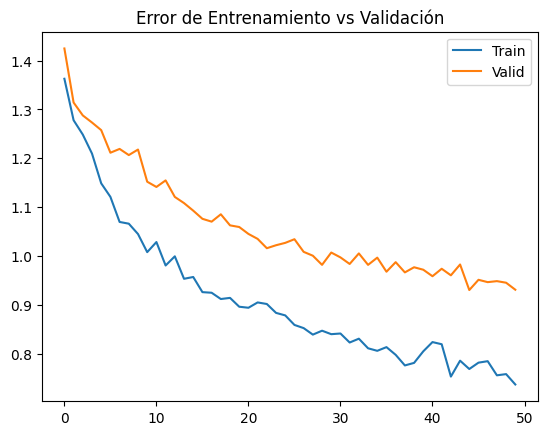

In [ ]:
plt.plot(history["train_loss"])
plt.plot(history["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

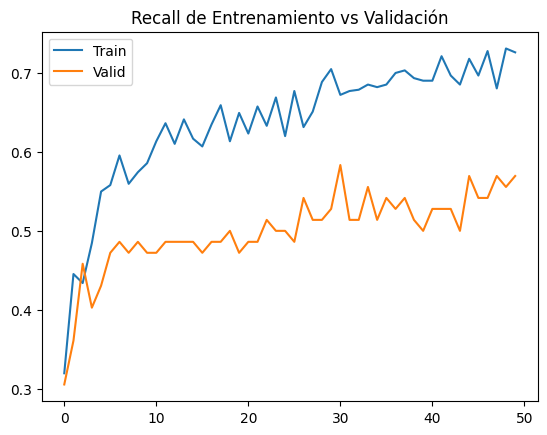

In [ ]:
plt.plot(history["train_metric"])
plt.plot(history["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

### Métricas

In [ ]:
print(f"Métrica final en train: {history["train_metric"][-1]}")
print(f"Métrica final en validation: {history["valid_metric"][-1]}")
print(f"Métrica final en validation: {history["test_metric"]}")

Métrica final en train: 0.7259380221366882
Métrica final en validation: 0.5694444179534912
Métrica final en validation: 0.6380952596664429


### Classification Report

In [ ]:
report = classification_report(y_true=history["labels_last_epoch"].cpu(), y_pred=history["pred_last_epoch"].argmax(dim=1).cpu(), target_names=CLASS_LABELS)
print(report)

                         precision    recall  f1-score   support

         adenocarcinoma       0.60      0.62      0.61       120
   large.cell.carcinoma       0.59      0.20      0.29        51
                 normal       1.00      1.00      1.00        54
squamous.cell.carcinoma       0.53      0.69      0.60        90

               accuracy                           0.64       315
              macro avg       0.68      0.63      0.63       315
           weighted avg       0.64      0.64      0.62       315



### Matriz de confusión

En la siguiente `Matriz de Confusión` se observa que el modelo clasifica correctamente a la clase `Normal`.

En cuanto al resto de las clases, presenta ciertas confusiones con las clases pertenecientes a enfermedades, pero **NO** las confunde con las clase `Normal`.

In [ ]:
cm = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

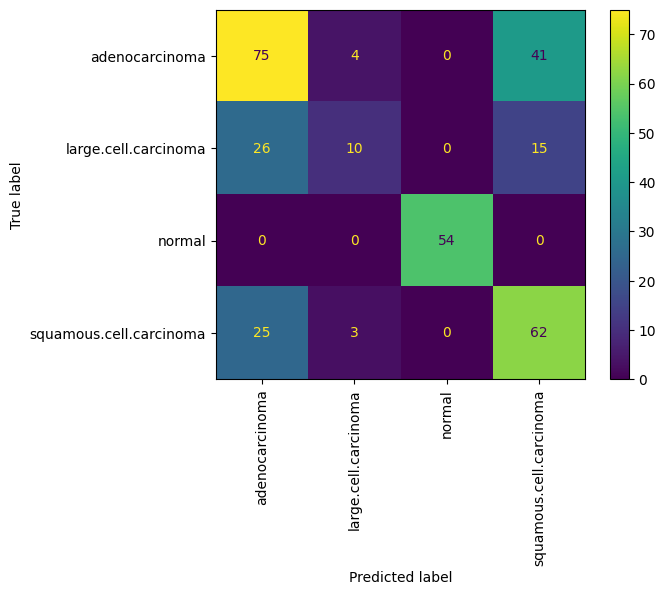

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()

### Matriz de confusión normalizada por fila

En la matriz de confusión normalizada por fila observamos que:

1. La clase `Normal` la recupera el $100%$ de las veces.
1. A la clase `Adenocarcinoma` la recupera el $62%$ de las veces, confundiendo un $3%$ de las veces con `Large Cell Carcinoma` y un $34%$ con `Squamous Cell Carcinoma`.
1. A la clase `Large Cell Carcinoma` la recupera el $20%$ de las veces, confundiendo un $51%$ de las veces con `Adenocarcinoma` y un $29%$ con `Squamous Cell Carcinoma`.
1. A la clase `Squamous Cell Carcinoma` la recupera el $69%$ de las veces, confundiendo un $28%$ de las veces con `Adenocarcinoma` y un $3.3%$ con `Large Cell Carcinoma`.

In [ ]:
cm_normalized_by_row = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

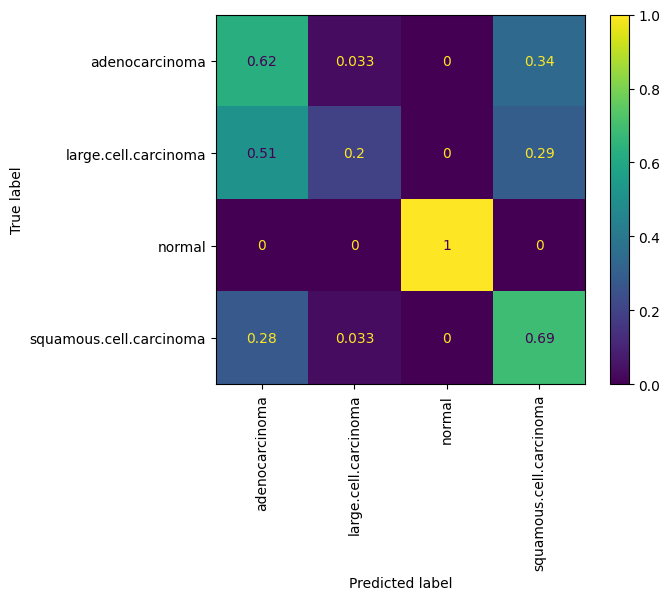

In [ ]:
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=CLASS_LABELS)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()

## ResNet 152 - Transformaciones lineales - Transfer Learning

### Definición del modelo

Se estudia un modelo basado en `ResNet 152`, en donde se modifica la última capa con una secuencia de transformaciones lineales afines.

Sea nuestro `bloque de transformación afin` el siguiente:

1. Transformación Lineal mediante `torch.nn.Linear`, en donde se reduce a la mitad la cantidad de input.
1. Regularización mediante `torch.nn.BatchNormalization1d`, con input igual a la salida del paso Linear anterior.
1. Función de Activación `torch.nn.ReLU`.
1. Regularización mediante `torch.nn.DropOut`, con $30%$.

Nuestra última capa se compone de:

1. `Bloque de transformación afin` con input $2048$ y output $1024$.
1. `Bloque de transformación afin` con input $1024$ y output $512$.
1. `Bloque de transformación afin` con input $512$ y output $256$.
1. Transformación Lineal Afin mediante `torch.nn.Linear` con input $256$ y output $4$ (cantidad de clases).

Básicamente, buscamos estudiar el impacto que tiene una serie de transformaciones afines que reducen el tamaño de los datos estudiados de $2048$ a $256$, es decir, un valor cercano al tamaño de nuestras imágenes de $224x224$. Finalmente, se aplica una última capa lineal para tener el output de $4$ clases a clasificar.

Además, implementamos ***Transfer Learning***, por lo cual utilizamos los pesos obtenidos al entrenar el modelo ResNet152 (`ResNet152_Weights.IMAGENET1K_V1`).

In [ ]:
weights = ResNet152_Weights.IMAGENET1K_V1
resnet152_alternative_model = resnet152(weights=weights)
resnet152_alternative_model.to(device);

In [ ]:
for param in resnet152_alternative_model.parameters():
    param.requires_grad = False

In [ ]:
DROPOUT = 0.3

In [ ]:
last_layer_in_features = resnet152_alternative_model.fc.in_features
resnet152_alternative_model.fc = torch.nn.Sequential(
    ##### 2048 -> 1024
    torch.nn.Linear(in_features=last_layer_in_features, out_features=int(last_layer_in_features/2)),
    torch.nn.BatchNorm1d(num_features=int(last_layer_in_features/2)),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=DROPOUT, inplace=False),
    ##### 1024 -> 512
    torch.nn.Linear(in_features=int(last_layer_in_features/2), out_features=int(last_layer_in_features/4)),
    torch.nn.BatchNorm1d(num_features=int(last_layer_in_features/4)),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=DROPOUT, inplace=False),
    ##### 512 -> 256
    torch.nn.Linear(in_features=int(last_layer_in_features/4), out_features=int(last_layer_in_features/8)),
    torch.nn.BatchNorm1d(num_features=int(last_layer_in_features/8)),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=DROPOUT, inplace=False),
    ##### Linear: 256 -> OUTPUTS (4)
    torch.nn.Linear(in_features=int(last_layer_in_features/8), out_features=OUTPUTS)
  )

In [ ]:
resnet152_alternative_model.to(device);

### Entrenamiento

Entrenamos el modelos con un Learning Rate de `1e-4` y con $100$ EPOCHS.

In [ ]:
model = resnet152_alternative_model

In [ ]:
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LEARNING_RATE)

In [ ]:
history_resnet152_alternative = train_eval_loop(
    model=model, optimizer=optimizer, criterion=criterion, metric=metric,
    data=data, epochs=EPOCHS)

Época 1/100 | Train loss: 1.2480 - Train recall: 0.4095 | Valid loss: 1.2917 - Valid recall: 0.4583
Época 2/100 | Train loss: 1.0096 - Train recall: 0.5824 | Valid loss: 1.1331 - Valid recall: 0.4583
Época 3/100 | Train loss: 0.9084 - Train recall: 0.6183 | Valid loss: 0.9894 - Valid recall: 0.4722
Época 4/100 | Train loss: 0.8240 - Train recall: 0.6786 | Valid loss: 0.9374 - Valid recall: 0.5417
Época 5/100 | Train loss: 0.7676 - Train recall: 0.6933 | Valid loss: 0.9269 - Valid recall: 0.6111
Época 6/100 | Train loss: 0.7904 - Train recall: 0.7129 | Valid loss: 0.8981 - Valid recall: 0.5972
=====No hay mejora en Valid Loss por 1 épocas.
Época 8/100 | Train loss: 0.6887 - Train recall: 0.7308 | Valid loss: 0.8406 - Valid recall: 0.6944
=====No hay mejora en Valid Loss por 1 épocas.
Época 10/100 | Train loss: 0.6162 - Train recall: 0.7667 | Valid loss: 0.8297 - Valid recall: 0.5972
Época 11/100 | Train loss: 0.6000 - Train recall: 0.7732 | Valid loss: 0.7818 - Valid recall: 0.6389
====

In [ ]:
history = history_resnet152_alternative

### Gráficos

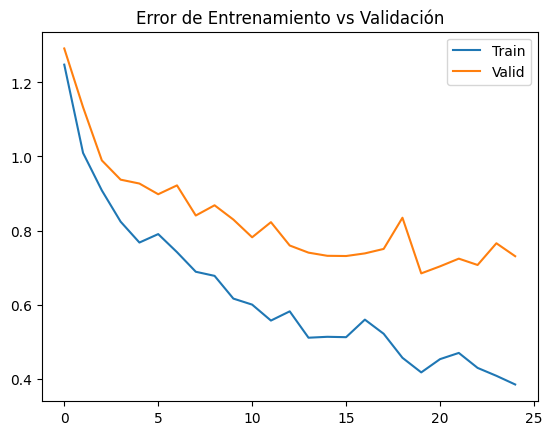

In [ ]:
plt.plot(history["train_loss"])
plt.plot(history["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

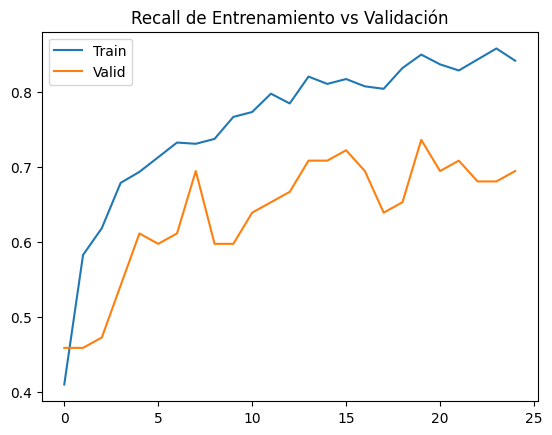

In [ ]:
plt.plot(history["train_metric"])
plt.plot(history["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])


### Métricas

In [ ]:
print(f"Métrica final en train: {history["train_metric"][-1]}")
print(f"Métrica final en validation: {history["valid_metric"][-1]}")
print(f"Métrica final en validation: {history["test_metric"]}")

Métrica final en train: 0.8417618274688721
Métrica final en validation: 0.6944444179534912
Métrica final en validation: 0.720634937286377


### Classification Report

In [ ]:
report = classification_report(y_true=history["labels_last_epoch"].cpu(), y_pred=history["pred_last_epoch"].argmax(dim=1).cpu(), target_names=CLASS_LABELS)
print(report)

                         precision    recall  f1-score   support

         adenocarcinoma       0.75      0.54      0.63       120
   large.cell.carcinoma       0.93      0.55      0.69        51
                 normal       0.92      1.00      0.96        54
squamous.cell.carcinoma       0.58      0.89      0.70        90

               accuracy                           0.72       315
              macro avg       0.79      0.74      0.74       315
           weighted avg       0.76      0.72      0.71       315



### Matriz de confusión

En la siguiente `Matriz de Confusión` se observa que el modelo clasifica correctamente a la clase `Normal`.

El resto de las clases NO son recuperadas en su totalidad, habiendo casos en donde son confundidas con las clase `Normal`.

In [ ]:
cm = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

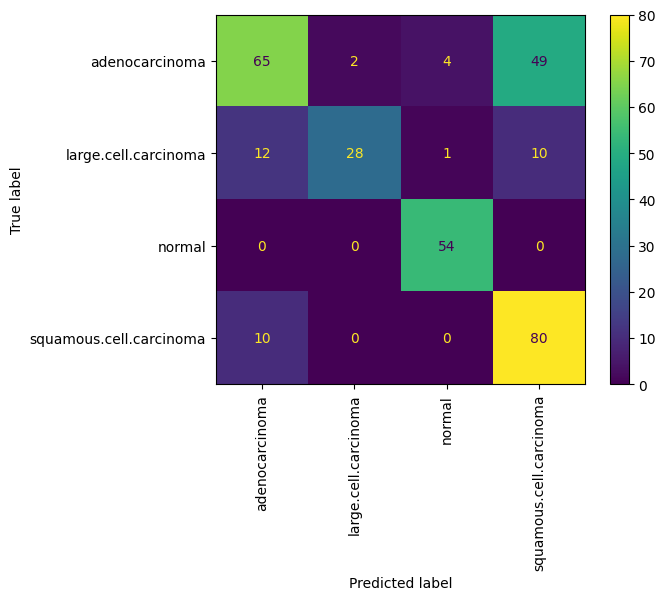

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()

### Matriz de confusión normalizada por fila

En la matriz de confusión normalizada por fila observamos que:

1. La clase `Normal` la recupera el $100%$ de las veces.
1. A la clase `Adenocarcinoma` la recupera el $54%$ de las veces, confundiendo un $1.7%$ de las veces con `Large Cell Carcinoma` y un $41%$ con `Squamous Cell Carcinoma`. También la confunde el $3.3%$ de las veces con la clase `Normal`.
1. A la clase `Large Cell Carcinoma` la recupera el $55%$ de las veces, confundiendo un $24%$ de las veces con `Adenocarcinoma` y un $20%$ con `Squamous Cell Carcinoma`. También la confunde el $2%$ de las veces con la clase `Normal`.
1. A la clase `Squamous Cell Carcinoma` la recupera el $89%$ de las veces, confundiendo un $11%$ de las veces con `Adenocarcinoma`.

In [ ]:
cm_normalized_by_row = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

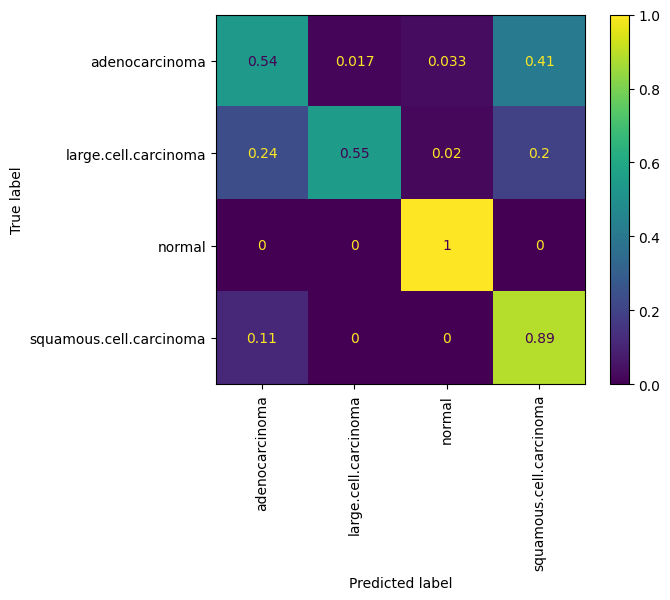

In [ ]:
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=CLASS_LABELS)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()

## ResNet 152 - Convoluciones en última capa - Transfer Learning

### Definición del modelo

Se estudia un modelo basado en `ResNet 152`, en donde se modifica la última capa con una secuencia de convoluciones.

Sea nuestro `bloque de convolución` el siguiente:

1. Convolución mediante `torch.nn.Conv2d` de input $N$ y output $N/2$, con Kernel Size de $1$.
1. Regularización mediante `torch.nn.BatchNorm2d` de input igual a la salida de la convolución anterior ($N/2$).
1. Función de Activación `torch.nn.ReLU`.
1. Regularización mediante `torch.nn.DropOut`, con $30%$.

Nuestra última capa se compone de:

1. `Bloque de convolución` con input $2048$ y output $1024$.
1. `Bloque de convolución` con input $1024$ y output $512$.
1. `Bloque de convolución` con input $512$ y output $256$.
1. Adaptive Average Pooling mediante `torch.nn.AdaptiveAvgPool2d`.
1. Aplanado mediante `torch.nn.Flatten`.
1. Transformación Lineal Afin mediante `torch.nn.Linear` con input $256$ y output $4$ (cantidad de clases).

Mediante esta capa buscamos estudiar como una serie de convoluciones que reducen el output de la penúltima capa del modelo `ResNet152` base a la mitad hasta *llegar* a un valor próximo al tamaño de nuestras imágenes del dataset ($224x224$) afectan en la predicción de las clases (realizado en las últimas capas).

El valor de `Kernel size` ($1$) fue elegido a fin de facilitar el cálculo de los outputs de la red. Éste consiste en un hiperparámetro de la red, por lo cuál podría ser estudiado mediante optimización de hiperparámetros en futuros experimentos.

Además, implementamos ***Transfer Learning***, por lo cual utilizamos los pesos obtenidos al entrenar el modelo ResNet152 (`ResNet152_Weights.IMAGENET1K_V1`).

In [ ]:
weights = ResNet152_Weights.IMAGENET1K_V1
original_resnet152 = resnet152(weights=weights)
original_resnet152.to(device);

In [ ]:
for param in original_resnet152.parameters():
    param.requires_grad = False

In [ ]:
features = torch.nn.Sequential(*list(original_resnet152.children())[:-1])

In [ ]:
class ResNet152WithCustomConvolutions(torch.nn.Module):
    def __init__(self, features, new_layer):
        super().__init__()
        self.features = features
        self.new_layer = new_layer

    def forward(self, x):
        x = self.features(x)
        x = self.new_layer(x)
        return x

In [ ]:
last_layer_in_features = original_resnet152.fc.in_features

In [ ]:
DROPOUT = 0.3

In [ ]:
seq = torch.nn.Sequential(
    ##### 2048 -> 1024
    torch.nn.Conv2d(last_layer_in_features, last_layer_in_features//2, kernel_size=1),
    torch.nn.BatchNorm2d(num_features=last_layer_in_features//2),
    torch.nn.ReLU(inplace=True),
    torch.nn.Dropout(p=DROPOUT),
    ##### 1024 -> 512
    torch.nn.Conv2d(last_layer_in_features//2, last_layer_in_features//4, kernel_size=1),
    torch.nn.BatchNorm2d(num_features=last_layer_in_features//4),
    torch.nn.ReLU(inplace=True),
    torch.nn.Dropout(p=DROPOUT),
    ##### 512 -> 256
    torch.nn.Conv2d(last_layer_in_features//4, last_layer_in_features//8, kernel_size=1),
    torch.nn.BatchNorm2d(num_features=last_layer_in_features//8),
    torch.nn.ReLU(inplace=True),
    torch.nn.Dropout(p=DROPOUT),
    #### Adaptive Pooling 2d
    torch.nn.AdaptiveAvgPool2d(output_size=(1, 1)),
    torch.nn.Flatten(),
    ### Linear: 256 -> OUTPUTS (4)
    torch.nn.Linear(in_features=last_layer_in_features//8, out_features=OUTPUTS, bias=True)
  )

In [ ]:
resnet152CustomConvolutions = ResNet152WithCustomConvolutions(features, seq);
resnet152CustomConvolutions.to(device);

### Entrenamiento

Entrenamos el modelos con un Learning Rate de `1e-4` y con $100$ EPOCHS.

In [ ]:
model = resnet152CustomConvolutions

In [ ]:
optimizer = torch.optim.Adam(model.new_layer.parameters(), lr=LEARNING_RATE)

In [ ]:
history_resnet152_custom_convolutions = train_eval_loop(
    model=model, optimizer=optimizer, criterion=criterion, metric=metric,
    data=data, epochs=EPOCHS)

Época 1/100 | Train loss: 1.2501 - Train recall: 0.4160 | Valid loss: 1.3130 - Valid recall: 0.3472
Época 2/100 | Train loss: 1.0307 - Train recall: 0.5922 | Valid loss: 1.1845 - Valid recall: 0.3889
Época 3/100 | Train loss: 0.8856 - Train recall: 0.6444 | Valid loss: 1.0169 - Valid recall: 0.4722
Época 4/100 | Train loss: 0.8770 - Train recall: 0.6656 | Valid loss: 0.9385 - Valid recall: 0.5556
Época 5/100 | Train loss: 0.8392 - Train recall: 0.6460 | Valid loss: 0.9111 - Valid recall: 0.5972
Época 6/100 | Train loss: 0.7634 - Train recall: 0.7047 | Valid loss: 0.8860 - Valid recall: 0.5694
Época 7/100 | Train loss: 0.7059 - Train recall: 0.7504 | Valid loss: 0.8517 - Valid recall: 0.5972
=====No hay mejora en Valid Loss por 1 épocas.
Época 9/100 | Train loss: 0.6774 - Train recall: 0.7374 | Valid loss: 0.8359 - Valid recall: 0.6389
Época 10/100 | Train loss: 0.6627 - Train recall: 0.7798 | Valid loss: 0.7817 - Valid recall: 0.6667
Época 11/100 | Train loss: 0.6481 - Train recall: 0.

In [ ]:
history = history_resnet152_custom_convolutions

### Gráficos

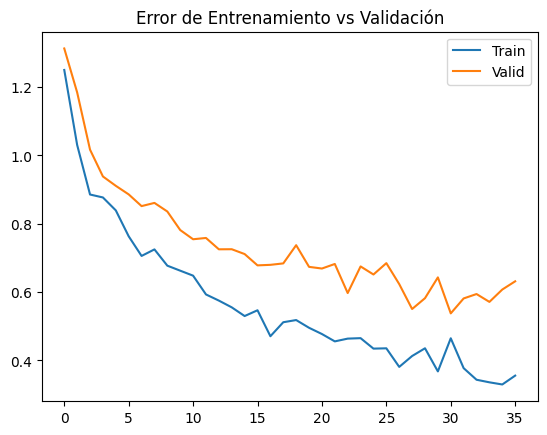

In [ ]:
plt.plot(history["train_loss"])
plt.plot(history["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

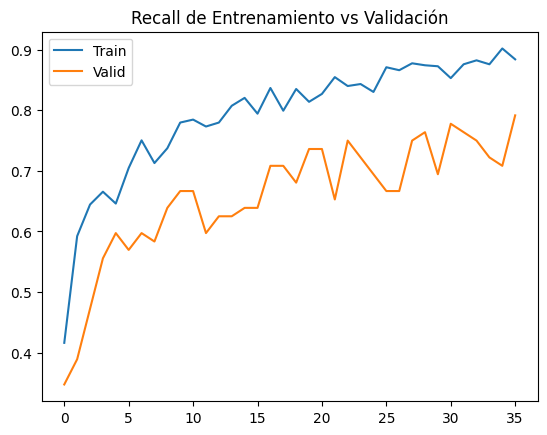

In [ ]:
plt.plot(history["train_metric"])
plt.plot(history["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

### Métricas

In [ ]:
print(f"Métrica final en train: {history["train_metric"][-1]}")
print(f"Métrica final en validation: {history["valid_metric"][-1]}")
print(f"Métrica final en validation: {history["test_metric"]}")

Métrica final en train: 0.8841761946678162
Métrica final en validation: 0.7916666865348816
Métrica final en validation: 0.7523809671401978


### Classification Report

In [ ]:
report = classification_report(y_true=history["labels_last_epoch"].cpu(), y_pred=history["pred_last_epoch"].argmax(dim=1).cpu(), target_names=CLASS_LABELS)
print(report)

                         precision    recall  f1-score   support

         adenocarcinoma       0.68      0.76      0.72       120
   large.cell.carcinoma       0.71      0.69      0.70        51
                 normal       0.92      1.00      0.96        54
squamous.cell.carcinoma       0.78      0.63      0.70        90

               accuracy                           0.75       315
              macro avg       0.77      0.77      0.77       315
           weighted avg       0.75      0.75      0.75       315



### Matriz de confusión

En la siguiente `Matriz de Confusión` se observa que el modelo clasifica correctamente a la clase `Normal`.

En cuanto al resto de las clases, presenta ciertas confusiones con las clases pertenecientes a enfermedades, como así también hay ciertas confusiones con la clase `Normal`.

In [ ]:
cm = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

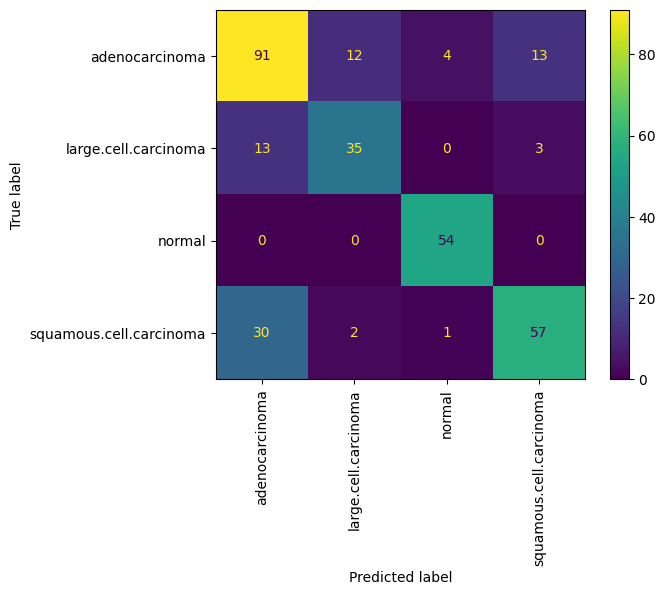

In [ ]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()

### Matriz de confusión normalizada por fila

En la matriz de confusión normalizada por fila observamos que:

1. La clase `Normal` la recupera el $100%$ de las veces.
1. A la clase `Adenocarcinoma` la recupera el $76%$ de las veces, confundiendo un $10%$ de las veces con `Large Cell Carcinoma` y un $11%$ con `Squamous Cell Carcinoma`. También la confunde el $3.3%$ de las veces con la clase `Normal`.
1. A la clase `Large Cell Carcinoma` la recupera el $69%$ de las veces, confundiendo un $25%$ de las veces con `Adenocarcinoma` y un $5.9%$ con `Squamous Cell Carcinoma`.
1. A la clase `Squamous Cell Carcinoma` la recupera el $63%$ de las veces, confundiendo un $33%$ de las veces con `Adenocarcinoma` y un $2.2%$ con `Large Cell Carcinoma`. También la confunde el $1.1%$ de las veces con la clase `Normal`.

In [ ]:
cm_normalized_by_row = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

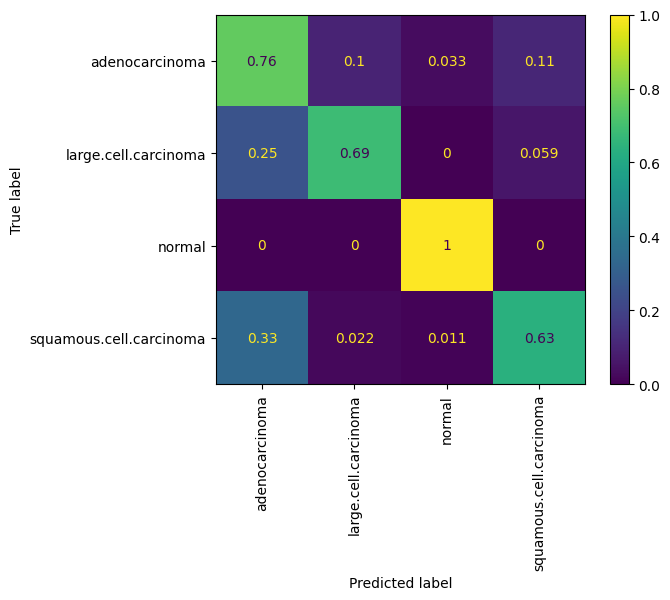

In [ ]:
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=CLASS_LABELS)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()

## ResNet 152 - Base- Fine Tuning

### Definición del modelo

En este caso se estudia un modelo basado en `ResNet152`, en donde solamente modificamos el ***OUTPUT*** de la última capa. Pasamos de $2048$ a $4$, que son la cantidad de clases a predecir.

Además, implementamos ***Fine Tuning***, por lo cual utilizamos los pesos obtenidos al entrenar el modelo ResNet152 (`ResNet152_Weights.DEFAULT`).

In [ ]:
from torchvision.models import resnet152, ResNet152_Weights

weights = ResNet152_Weights.DEFAULT
resnet152_model_ft = resnet152(weights=weights);
resnet152_model_ft.to(device);

In [ ]:
last_layer_in_features = resnet152_model_ft.fc.in_features
resnet152_model_ft.fc = torch.nn.Linear(in_features=last_layer_in_features, out_features=OUTPUTS)

In [ ]:
for param in resnet152_model_ft.parameters():
    param.requires_grad = True

### Entrenamiento

Entrenamos el modelos con un Learning Rate de `1e-4` y con $100$ EPOCHS.

In [ ]:
model = resnet152_model_ft

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
history_resnet152_ft = train_eval_loop(model=model, optimizer=optimizer,
                                       criterion=criterion, metric=metric,
                                       data=data, epochs=EPOCHS)

Época 1/100 | Train loss: 1.1798 - Train recall: 0.5188 | Valid loss: 1.1999 - Valid recall: 0.5278
Época 2/100 | Train loss: 0.8007 - Train recall: 0.6998 | Valid loss: 0.9151 - Valid recall: 0.5972
Época 3/100 | Train loss: 0.5001 - Train recall: 0.8173 | Valid loss: 0.5731 - Valid recall: 0.7222
Época 4/100 | Train loss: 0.2821 - Train recall: 0.9184 | Valid loss: 0.4850 - Valid recall: 0.8056
Época 5/100 | Train loss: 0.2244 - Train recall: 0.9347 | Valid loss: 0.3655 - Valid recall: 0.8194
Época 6/100 | Train loss: 0.1722 - Train recall: 0.9396 | Valid loss: 0.3639 - Valid recall: 0.8333
Época 7/100 | Train loss: 0.0857 - Train recall: 0.9821 | Valid loss: 0.3221 - Valid recall: 0.8472
=====No hay mejora en Valid Loss por 1 épocas.
=====No hay mejora en Valid Loss por 2 épocas.
=====No hay mejora en Valid Loss por 3 épocas.
=====No hay mejora en Valid Loss por 4 épocas.
Época 12/100 | Train loss: 0.1258 - Train recall: 0.9723 | Valid loss: 0.2609 - Valid recall: 0.8611
Época 13/10

In [ ]:
history = history_resnet152_ft

### Gráficos

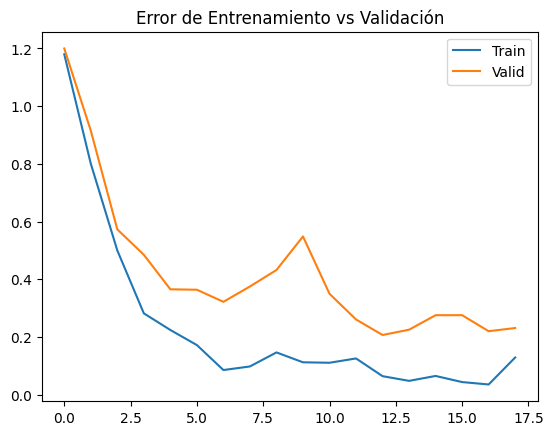

In [ ]:
plt.plot(history["train_loss"])
plt.plot(history["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

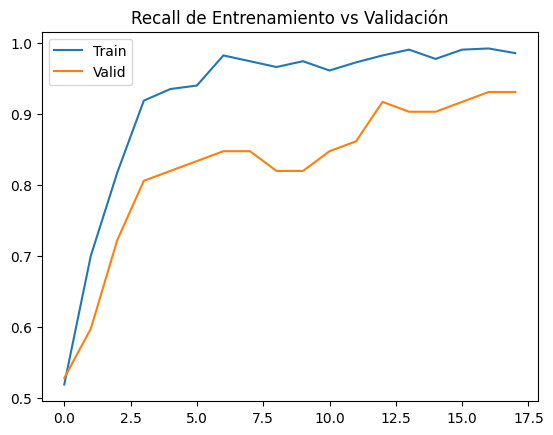

In [ ]:
plt.plot(history["train_metric"])
plt.plot(history["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

### Métricas

In [ ]:
print(f"Métrica final en train: {history["train_metric"][-1]}")
print(f"Métrica final en validation: {history["valid_metric"][-1]}")
print(f"Métrica final en validation: {history["test_metric"]}")

Métrica final en train: 0.985318124294281
Métrica final en validation: 0.9305555820465088
Métrica final en validation: 0.9142857193946838


### Classification Report

In [ ]:
report = classification_report(y_true=history["labels_last_epoch"].cpu(), y_pred=history["pred_last_epoch"].argmax(dim=1).cpu(), target_names=CLASS_LABELS)
print(report)

                         precision    recall  f1-score   support

         adenocarcinoma       0.96      0.81      0.88       120
   large.cell.carcinoma       0.89      0.94      0.91        51
                 normal       1.00      0.98      0.99        54
squamous.cell.carcinoma       0.84      1.00      0.91        90

               accuracy                           0.91       315
              macro avg       0.92      0.93      0.92       315
           weighted avg       0.92      0.91      0.91       315



### Matriz de confusión

En la siguiente `Matriz de Confusión` se observa que el modelo clasifica correctamente a la clase `Normal`.

En cuanto al resto de las clases, presenta ciertas confusiones con las clases pertenecientes a enfermedades, pero **NO** las confunde con la clase `Normal`.

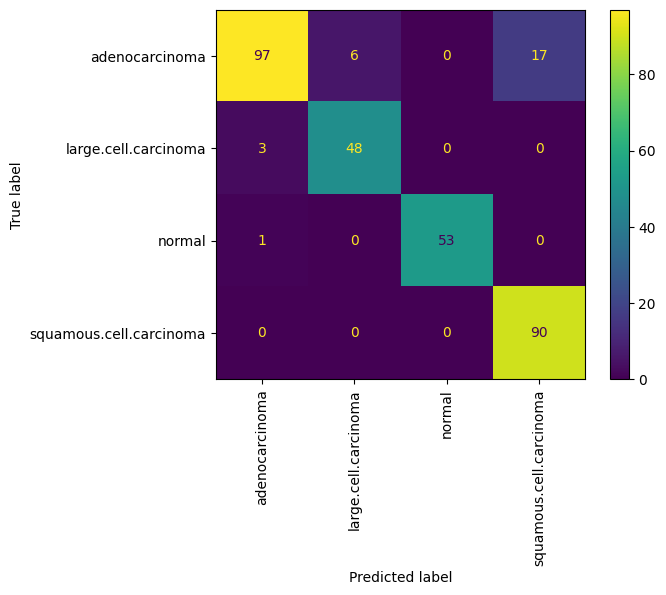

In [ ]:
cm = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)

### Matriz de confusión normalizada por fila

En la matriz de confusión normalizada por fila observamos que:

1. La clase `Normal` la recupera el $98%$ de las veces. El resto de las veces la confunce con la clase `Adenocarcinoma`.
1. A la clase `Adenocarcinoma` la recupera el $81%$ de las veces, confundiendo un $5%$ de las veces con `Large Cell Carcinoma` y un $15%$ con `Squamous Cell Carcinoma`.
1. A la clase `Large Cell Carcinoma` la recupera el $94%$ de las veces, confundiendo un $6%$ de las veces con `Adenocarcinoma`.
1. A la clase `Squamous Cell Carcinoma` la recupera el $100%$ de las veces.

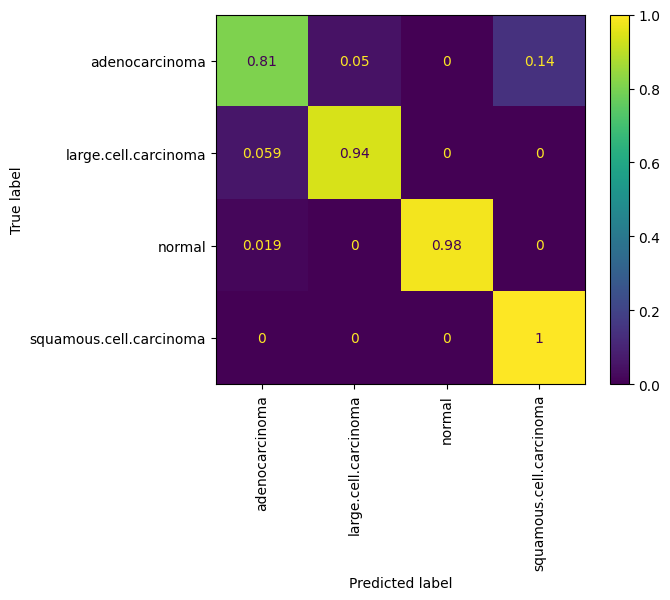

In [ ]:
cm_normalized_by_row = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=CLASS_LABELS)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()

## ResNet 152 - Transformaciones lineales - Fine Tuning

### Definición del modelo

Se estudia un modelo basado en `ResNet 152`, en donde se modifica la última capa con una secuencia de transformaciones lineales afines.

Sea nuestro `bloque de transformación afin` el siguiente:

1. Transformación Lineal mediante `torch.nn.Linear`, en donde se reduce a la mitad la cantidad de input.
1. Regularización mediante `torch.nn.BatchNormalization1d`, con input igual a la salida del paso Linear anterior.
1. Función de Activación `torch.nn.ReLU`.
1. Regularización mediante `torch.nn.DropOut`, con $30%$.

Nuestra última capa se compone de:

1. `Bloque de transformación afin` con input $2048$ y output $1024$.
1. `Bloque de transformación afin` con input $1024$ y output $512$.
1. `Bloque de transformación afin` con input $512$ y output $256$.
1. Transformación Lineal Afin mediante `torch.nn.Linear` con input $256$ y output $4$ (cantidad de clases).

Básicamente, buscamos estudiar el impacto que tiene una serie de transformaciones afines que reducen el tamaño de los datos estudiados de $2048$ a $256$, es decir, un valor cercano al tamaño de nuestras imágenes de $224x224$. Finalmente, se aplica una última capa lineal para tener el output de $4$ clases a clasificar.

Además, implementamos ***Fine Tuning***, por lo cual utilizamos los pesos obtenidos al entrenar el modelo ResNet152 (`ResNet152_Weights.DEFAULT`).

In [ ]:
weights = ResNet152_Weights.DEFAULT
resnet152_lineal_ft = resnet152(weights=weights)
resnet152_lineal_ft.to(device);

In [ ]:
DROPOUT = 0.3

In [ ]:
last_layer_in_features = resnet152_lineal_ft.fc.in_features
resnet152_lineal_ft.fc = torch.nn.Sequential(
    ##### 2048 -> 1024
    torch.nn.Linear(in_features=last_layer_in_features, out_features=int(last_layer_in_features/2)),
    torch.nn.BatchNorm1d(num_features=int(last_layer_in_features/2)),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=DROPOUT, inplace=False),
    ##### 1024 -> 512
    torch.nn.Linear(in_features=int(last_layer_in_features/2), out_features=int(last_layer_in_features/4)),
    torch.nn.BatchNorm1d(num_features=int(last_layer_in_features/4)),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=DROPOUT, inplace=False),
    ##### 512 -> 256
    torch.nn.Linear(in_features=int(last_layer_in_features/4), out_features=int(last_layer_in_features/8)),
    torch.nn.BatchNorm1d(num_features=int(last_layer_in_features/8)),
    torch.nn.ReLU(),
    torch.nn.Dropout(p=DROPOUT, inplace=False),
    ##### Linear: 256 -> OUTPUTS (4)
    torch.nn.Linear(in_features=int(last_layer_in_features/8), out_features=OUTPUTS)
  )

In [ ]:
for param in resnet152_model_ft.parameters():
    param.requires_grad = True

In [ ]:
resnet152_lineal_ft.to(device);

### Entrenamiento

Entrenamos el modelos con un Learning Rate de `1e-4` y con $100$ EPOCHS.

In [ ]:
model = resnet152_lineal_ft

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
history_resnet152_lineal_ft = train_eval_loop(
    model=model, optimizer=optimizer, criterion=criterion, metric=metric,
    data=data, epochs=EPOCHS)

Época 1/100 | Train loss: 1.4001 - Train recall: 0.3132 | Valid loss: 1.3179 - Valid recall: 0.3333
Época 2/100 | Train loss: 1.0924 - Train recall: 0.5449 | Valid loss: 1.2258 - Valid recall: 0.4444
Época 3/100 | Train loss: 0.9570 - Train recall: 0.6117 | Valid loss: 1.0328 - Valid recall: 0.5417
Época 4/100 | Train loss: 0.8398 - Train recall: 0.6737 | Valid loss: 1.0299 - Valid recall: 0.5139
Época 5/100 | Train loss: 0.7268 - Train recall: 0.7080 | Valid loss: 0.9124 - Valid recall: 0.5000
Época 6/100 | Train loss: 0.6789 - Train recall: 0.7390 | Valid loss: 0.7819 - Valid recall: 0.5972
Época 7/100 | Train loss: 0.5640 - Train recall: 0.8369 | Valid loss: 0.7354 - Valid recall: 0.6528
Época 8/100 | Train loss: 0.4682 - Train recall: 0.8564 | Valid loss: 0.6352 - Valid recall: 0.6667
Época 9/100 | Train loss: 0.3255 - Train recall: 0.9152 | Valid loss: 0.5946 - Valid recall: 0.7778
Época 10/100 | Train loss: 0.3054 - Train recall: 0.9152 | Valid loss: 0.5088 - Valid recall: 0.7361

In [ ]:
history = history_resnet152_lineal_ft

### Gráficos

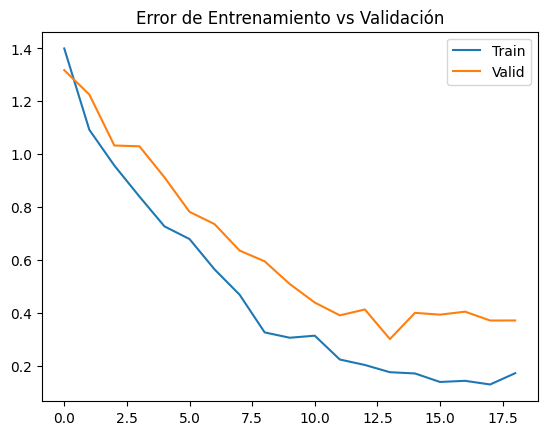

In [ ]:
plt.plot(history["train_loss"])
plt.plot(history["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

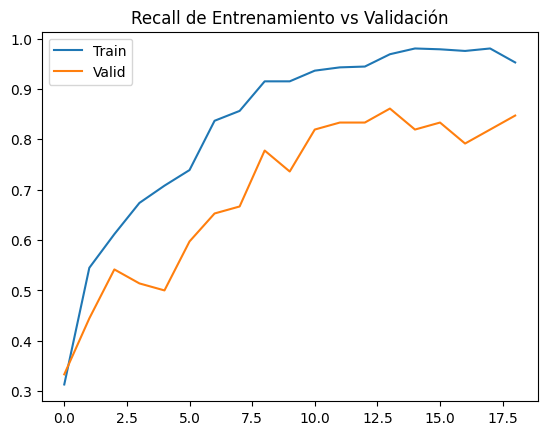

In [ ]:
plt.plot(history["train_metric"])
plt.plot(history["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

### Métricas

In [ ]:
print(f"Métrica final en train: {history["train_metric"][-1]}")
print(f"Métrica final en validation: {history["valid_metric"][-1]}")
print(f"Métrica final en validation: {history["test_metric"]}")

Métrica final en train: 0.9526916742324829
Métrica final en validation: 0.8472222089767456
Métrica final en validation: 0.882539689540863


### Classification Report

In [ ]:
report = classification_report(y_true=history["labels_last_epoch"].cpu(), y_pred=history["pred_last_epoch"].argmax(dim=1).cpu(), target_names=CLASS_LABELS)
print(report)

                         precision    recall  f1-score   support

         adenocarcinoma       0.86      0.87      0.86       120
   large.cell.carcinoma       0.93      0.82      0.88        51
                 normal       1.00      0.94      0.97        54
squamous.cell.carcinoma       0.83      0.90      0.86        90

               accuracy                           0.88       315
              macro avg       0.90      0.88      0.89       315
           weighted avg       0.89      0.88      0.88       315



### Matriz de confusión

En la siguiente `Matriz de Confusión` se observa que el modelo clasifica correctamente a la clase `Normal`.

En cuanto al resto de las clases, presenta ciertas confusiones con las clases pertenecientes a enfermedades, pero **NO** las confunde con la clase `Normal`.

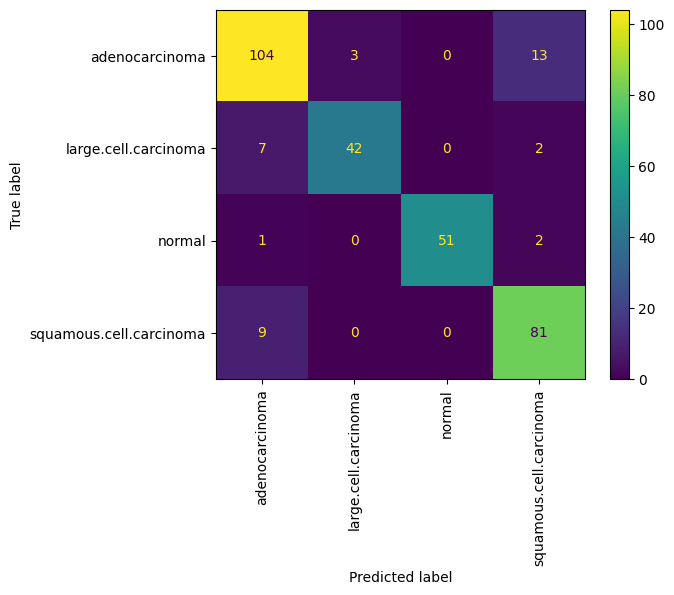

In [ ]:
cm = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()

### Matriz de confusión normalizada por fila

En la matriz de confusión normalizada por fila observamos que:

1. La clase `Normal` la recupera el $94%$ de las veces. Confunde esta clase con `Adenocarcinoma` el $1.9%$ de las veces, y con `Squamous Cell Carcinoma``el $3.7%$.
1. A la clase `Adenocarcinoma` la recupera el $87%$ de las veces, confundiendo un $2.5%$ de las veces con `Large Cell Carcinoma` y un $11%$ con `Squamous Cell Carcinoma`.
1. A la clase `Large Cell Carcinoma` la recupera el $82%$ de las veces, confundiendo un $14%$ de las veces con `Adenocarcinoma` y un $3.9%$ con `Squamous Cell Carcinoma`.
1. A la clase `Squamous Cell Carcinoma` la recupera el $90%$ de las veces, confundiendo un $10%$ de las veces con `Adenocarcinoma`.

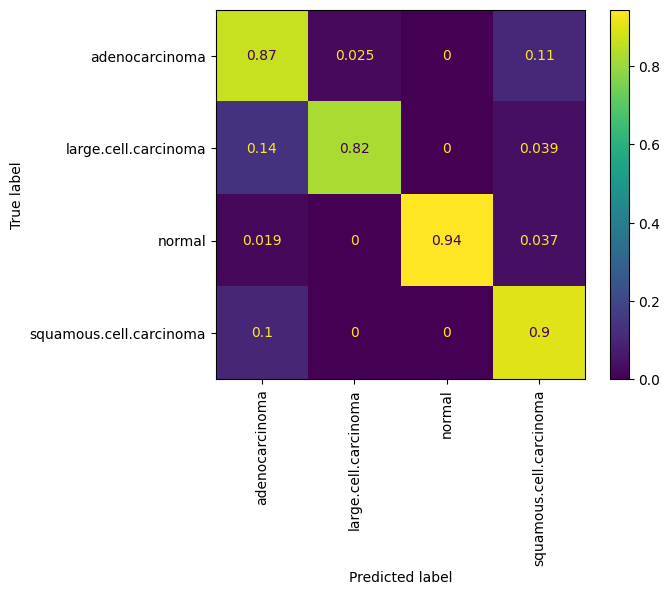

In [ ]:
cm_normalized_by_row = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=CLASS_LABELS)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()

## ResNet 152 - Convoluciones en última capa - Fine Tuning

### Definición del modelo

Se estudia un modelo basado en `ResNet 152`, en donde se modifica la última capa con una secuencia de convoluciones.

Sea nuestro `bloque de convolución` el siguiente:

1. Convolución mediante `torch.nn.Conv2d` de input $N$ y output $N/2$, con Kernel Size de $1$.
1. Regularización mediante `torch.nn.BatchNorm2d` de input igual a la salida de la convolución anterior ($N/2$).
1. Función de Activación `torch.nn.ReLU`.
1. Regularización mediante `torch.nn.DropOut`, con $30%$.

Nuestra última capa se compone de:

1. `Bloque de convolución` con input $2048$ y output $1024$.
1. `Bloque de convolución` con input $1024$ y output $512$.
1. `Bloque de convolución` con input $512$ y output $256$.
1. Adaptive Average Pooling mediante `torch.nn.AdaptiveAvgPool2d`.
1. Aplanado mediante `torch.nn.Flatten`.
1. Transformación Lineal Afin mediante `torch.nn.Linear` con input $256$ y output $4$ (cantidad de clases).

Mediante esta capa buscamos estudiar como una serie de convoluciones que reducen el output de la penúltima capa del modelo `ResNet152` base a la mitad hasta *llegar* a un valor próximo al tamaño de nuestras imágenes del dataset ($224x224$) afectan en la predicción de las clases (realizado en las últimas capas).

El valor de `Kernel size` ($1$) fue elegido a fin de facilitar el cálculo de los outputs de la red. Éste consiste en un hiperparámetro de la red, por lo cuál podría ser estudiado mediante optimización de hiperparámetros en futuros experimentos.

Además, implementamos ***Fine Tuning***, por lo cual utilizamos los pesos obtenidos al entrenar el modelo ResNet152 (`ResNet152_Weights.DEFAULT`).

In [ ]:
weights = ResNet152_Weights.DEFAULT
original_resnet152 = resnet152(weights=weights)
original_resnet152.to(device);

In [ ]:
features = torch.nn.Sequential(*list(original_resnet152.children())[:-1])
last_layer_in_features = original_resnet152.fc.in_features

In [ ]:
DROPOUT = 0.3

In [ ]:
seq = torch.nn.Sequential(
    ##### 2048 -> 1024
    torch.nn.Conv2d(last_layer_in_features, last_layer_in_features//2, kernel_size=1),
    torch.nn.BatchNorm2d(num_features=last_layer_in_features//2),
    torch.nn.ReLU(inplace=True),
    torch.nn.Dropout(p=DROPOUT),
    ##### 1024 -> 512
    torch.nn.Conv2d(last_layer_in_features//2, last_layer_in_features//4, kernel_size=1),
    torch.nn.BatchNorm2d(num_features=last_layer_in_features//4),
    torch.nn.ReLU(inplace=True),
    torch.nn.Dropout(p=DROPOUT),
    ##### 512 -> 256
    torch.nn.Conv2d(last_layer_in_features//4, last_layer_in_features//8, kernel_size=1),
    torch.nn.BatchNorm2d(num_features=last_layer_in_features//8),
    torch.nn.ReLU(inplace=True),
    torch.nn.Dropout(p=DROPOUT),
    #### Adaptive Pooling 2d
    torch.nn.AdaptiveAvgPool2d(output_size=(1, 1)),
    torch.nn.Flatten(),
    ### Linear: 256 -> OUTPUTS (4)
    torch.nn.Linear(in_features=last_layer_in_features//8, out_features=OUTPUTS, bias=True)
  )

In [ ]:
resnet152CustomConvolutions_ft = ResNet152WithCustomConvolutions(features, seq);
resnet152CustomConvolutions_ft.to(device);

In [ ]:
for param in resnet152CustomConvolutions_ft.parameters():
    param.requires_grad = True

### Entrenamiento

Entrenamos el modelos con un Learning Rate de `1e-4` y con $100$ EPOCHS.

In [ ]:
model = resnet152CustomConvolutions_ft

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
history_resnet152_custom_convolutions_ft = train_eval_loop(
    model=model, optimizer=optimizer, criterion=criterion, metric=metric,
    data=data, epochs=EPOCHS)

Época 1/100 | Train loss: 1.3328 - Train recall: 0.3622 | Valid loss: 1.3369 - Valid recall: 0.4028
Época 2/100 | Train loss: 1.0568 - Train recall: 0.5579 | Valid loss: 1.1674 - Valid recall: 0.3889
Época 3/100 | Train loss: 0.9203 - Train recall: 0.5987 | Valid loss: 1.1231 - Valid recall: 0.4306
Época 4/100 | Train loss: 0.8214 - Train recall: 0.7080 | Valid loss: 0.9142 - Valid recall: 0.5139
Época 5/100 | Train loss: 0.6749 - Train recall: 0.7586 | Valid loss: 0.8471 - Valid recall: 0.5556
Época 6/100 | Train loss: 0.5467 - Train recall: 0.8108 | Valid loss: 0.7936 - Valid recall: 0.6667
Época 7/100 | Train loss: 0.5359 - Train recall: 0.8352 | Valid loss: 0.6982 - Valid recall: 0.6528
Época 8/100 | Train loss: 0.4548 - Train recall: 0.8728 | Valid loss: 0.5265 - Valid recall: 0.7083
Época 9/100 | Train loss: 0.3903 - Train recall: 0.8940 | Valid loss: 0.4428 - Valid recall: 0.8472
Época 10/100 | Train loss: 0.3441 - Train recall: 0.9021 | Valid loss: 0.3792 - Valid recall: 0.8333

In [ ]:
history = history_resnet152_custom_convolutions_ft

### Gráficos

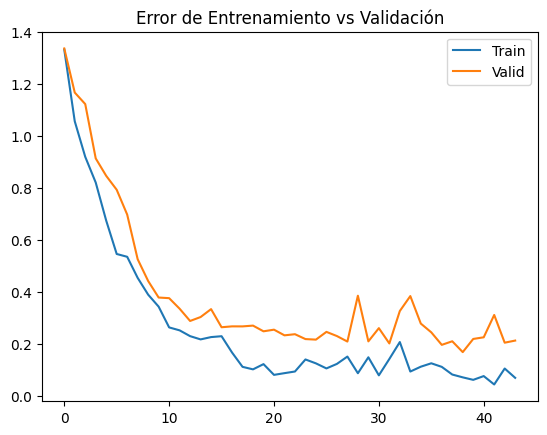

In [ ]:
plt.plot(history["train_loss"])
plt.plot(history["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

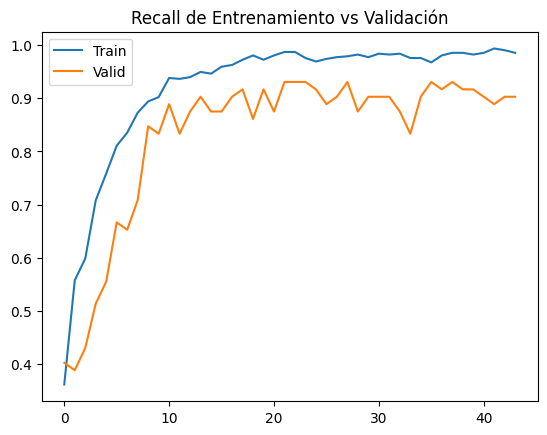

In [ ]:
plt.plot(history["train_metric"])
plt.plot(history["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

### Métricas

In [ ]:
print(f"Métrica final en train: {history["train_metric"][-1]}")
print(f"Métrica final en validation: {history["valid_metric"][-1]}")
print(f"Métrica final en validation: {history["test_metric"]}")

Métrica final en train: 0.985318124294281
Métrica final en validation: 0.9027777910232544
Métrica final en validation: 0.9015873074531555


### Classification Report

In [ ]:
report = classification_report(y_true=history["labels_last_epoch"].cpu(), y_pred=history["pred_last_epoch"].argmax(dim=1).cpu(), target_names=CLASS_LABELS)
print(report)

                         precision    recall  f1-score   support

         adenocarcinoma       0.92      0.82      0.87       120
   large.cell.carcinoma       0.86      0.98      0.92        51
                 normal       1.00      1.00      1.00        54
squamous.cell.carcinoma       0.85      0.91      0.88        90

               accuracy                           0.90       315
              macro avg       0.91      0.93      0.92       315
           weighted avg       0.90      0.90      0.90       315



### Matriz de confusión

En la siguiente `Matriz de Confusión` se observa que el modelo clasifica correctamente a la clase `Normal`.

En cuanto al resto de las clases, presenta ciertas confusiones con las clases pertenecientes a enfermedades, pero **NO** las confunde con la clase `Normal`.


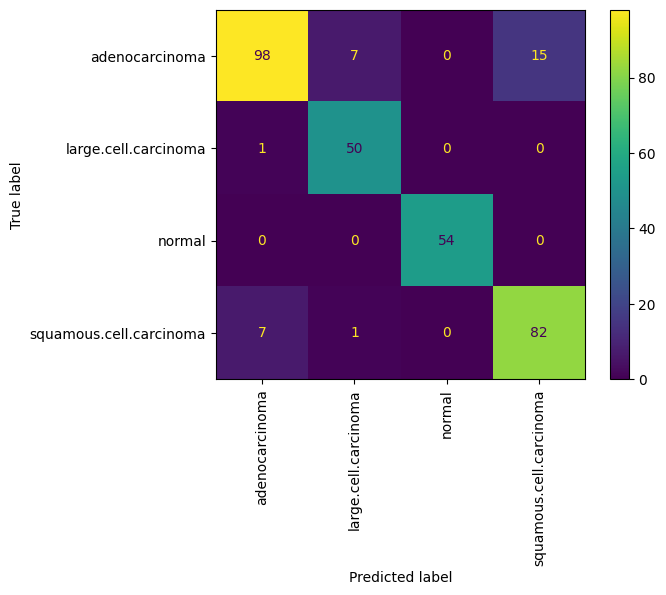

In [ ]:
cm = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LABELS)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()

### Matriz de confusión normalizada por fila

En la matriz de confusión normalizada por fila observamos que:

1. La clase `Normal` la recupera el $100%$ de las veces.
1. A la clase `Adenocarcinoma` la recupera el $82%$ de las veces, confundiendo un $5.8%$ de las veces con `Large Cell Carcinoma` y un $12%$ con `Squamous Cell Carcinoma`.
1. A la clase `Large Cell Carcinoma` la recupera el $98%$ de las veces, confundiendo un $2%$ de las veces con `Adenocarcinoma`.
1. A la clase `Squamous Cell Carcinoma` la recupera el $91%$ de las veces, confundiendo un $7.8%$ de las veces con `Adenocarcinoma` y un $1.1%$ con `Large Cell Carcinoma`.

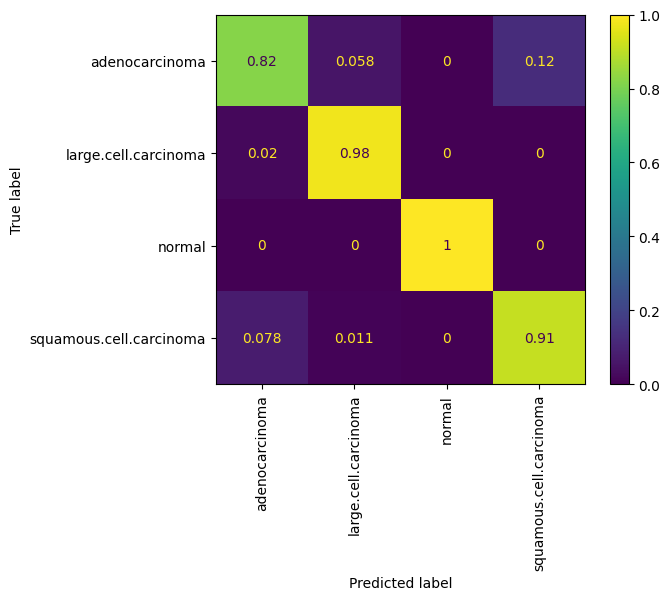

In [ ]:
cm_normalized_by_row = confusion_matrix(history["labels_last_epoch"].cpu(), history["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=CLASS_LABELS)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()